# Global Surface Water Storage (SWS) Analysis — Arid Regions

Compare lake/reservoir surface water storage anomalies (SWSA) with GRACE TWSA.

- **Baseline:** 2004–2009 mean removed
- **Units:** cm water equivalent
- **Arid mask:** Zomer AI ≤ 0.2 (`ai_v3_yr_mask_02_pol.shp`)
- **Functions:** [`sws_analysis_utils.py`](sws_analysis_utils.py)
- **Reference:** [`SWS_REFERENCE.md`](SWS_REFERENCE.md)

In [68]:
# Project paths: repo root + src/ on sys.path (run with cwd = repository root)
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    # Fallback if the notebook kernel cwd is notebooks/
    candidate = PROJECT_ROOT.parent
    if (candidate / "src").is_dir():
        PROJECT_ROOT = candidate
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

import importlib
import logging
import sys
from pathlib import Path
from sws_analysis_utils import load_hydrolakes_polygons, load_sws_config
import pandas as pd

%load_ext autoreload
%autoreload 2
from sws_analysis_utils import (
    load_sws_config,
    plot_lake_grace_precip_comparison,
    resolve_precip_path,
    run_download_all,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

ANALYSIS_START = "2004-04-01"
ANALYSIS_END = "2025-09-30"

cfg = load_sws_config()
cfg.data_root = RAW_DIR / "sws"
cfg.arid_areas_path = PROCESSED_DIR / "boundaries" / "ai_v3_yr_mask_02_pol.shp"
cfg.csr_grace_path = RAW_DIR / "grace" / "csr" / "CSR_GRACE_GRACE-FO_RL0603_Mascons_all-corrections.nc"
cfg.jpl_grace_path = RAW_DIR / "grace" / "jpl" / "GRCTellus.JPL.200204_202603.GLO.RL06.3M.MSCNv04CRI.nc"
cfg.gsfc_grace_path = RAW_DIR / "grace" / "gsfc" / "gsfc.glb_.200204_202511_rl06v2.0_obp-ice6gd_halfdegree.nc"
cfg.csr_mask_path = RAW_DIR / "grace" / "csr" / "CSR_GRACE_GRACE-FO_RL06_Mascons_v02_LandMask.nc"
cfg.reference_md = PROJECT_ROOT / "docs" / "SWS_REFERENCE.md"
cfg.ensure_dirs()
cfg.analysis_start = ANALYSIS_START
cfg.analysis_end = ANALYSIS_END

precip_path = resolve_precip_path(
    preferred=str(INTERIM_DIR / "gpm" / "GPM_3IMERGDF_Jan1998_Sep2025_resToM.zarr"),
    fallback=str(INTERIM_DIR / "gpm" / "GPM_3IMERGDF_Jan1998_Jun2024_resToM.zarr"),
)
cfg.precip_path = Path(precip_path)
print("Data root:", cfg.data_root)
print("Precip Zarr:", precip_path)
print("Process workers:", cfg.n_process_workers)
print("DAHITI key set:", bool(cfg.dahiti_api_key))
print("Hydroweb key set:", bool(cfg.hydroweb_api_key))


INFO: Using precipitation Zarr: /mnt/d/grace_ds/data/GPM/GPM_3IMERGDF/zarr_files/GPM_3IMERGDF_Jan1998_Sep2025_resToM.zarr
INFO: Using precipitation Zarr: /mnt/d/grace_ds/data/GPM/GPM_3IMERGDF/zarr_files/GPM_3IMERGDF_Jan1998_Sep2025_resToM.zarr


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Data root: /mnt/d/grace_ds/data/SWS
Precip Zarr: /mnt/d/grace_ds/data/GPM/GPM_3IMERGDF/zarr_files/GPM_3IMERGDF_Jan1998_Sep2025_resToM.zarr
Process workers: 10
DAHITI key set: True
Hydroweb key set: True


## 1. Dataset study (ranked for arid regions, 2002–2025)

| Rank | Dataset | Role |
|------|---------|------|
| 1 | **GloLakes** | Primary — ~24k lakes, monthly storage (MCM) |
| 2 | **DAHITI** | Validation — relative volume (km³), API key |
| 3 | **Hydroweb.next** | Major endorheic lakes (Aral, Chad), API key |
| 4 | **RECOG-LR** | GRACE lake leakage correction (phase 2 GRACE comparison) |

Arid lakes: HydroLAKES **polygon intersects** Zomer AI ≤ 0.2 mask (`filter_method="intersects"`).

See [`SWS_REFERENCE.md`](SWS_REFERENCE.md) for pros/cons, URLs, and known issues.

In [ ]:
#run_download_all(cfg)

In [2]:
from sws_analysis_utils import build_glolakes_arid_catalog
GLOLAKES_PRODUCT = "absolute_icesat2"  # or "absolute_icesat2" for absolute storage
GLOLAKES_VERSION = "v1.0"
SORT_BY = "area"   # "area" or "completeness_pc"

arid_catalog = build_glolakes_arid_catalog(
    product=GLOLAKES_PRODUCT,
    version=GLOLAKES_VERSION,
    cfg=cfg,
    sort_by=SORT_BY,
)
print(f"Arid GloLakes lakes: {len(arid_catalog)}")
arid_catalog.head(5)

  arid catalog (intersects): 1416 lakes → /mnt/d/grace_ds/data/SWS/catalog/glolakes_arid_absolute_icesat2.csv
Arid GloLakes lakes: 1416


,lake_id,lake_name,country,area_km2,geometry,lat,lon,dataset_source,lat_centroid,lon_centroid,in_arid
0,1431,Ngangla Ringco,China,498.06,"POLYGON ((83.10972 31.65431, 83.11164 31.65382...",31.572918,83.052086,GloLakes_absolute_icesat2,31.542796,83.077576,True
1,1435,Hamun-E Saberi,Afghanistan,488.53,"POLYGON ((61.36027 31.57722, 61.36123 31.5739,...",31.489582,61.297916,GloLakes_absolute_icesat2,31.401149,61.277147,True
2,1308,No Name,Turkmenistan,417.16,"POLYGON ((61.4646 41.30751, 61.46582 41.30748,...",41.219166,61.403126,GloLakes_absolute_icesat2,41.166932,61.556859,True
3,995,Musters,Argentina,410.52,"POLYGON ((-69.16194 -45.22471, -69.16222 -45.2...",-45.559723,-69.143753,GloLakes_absolute_icesat2,-45.414659,-69.195888,True
4,978,Los Barreales,Argentina,395.81,"POLYGON ((-68.75167 -38.44943, -68.75194 -38.4...",-38.578674,-68.688972,GloLakes_absolute_icesat2,-38.544934,-68.816980,True


In [3]:
#all > takes 36 min

from sws_analysis_utils import build_glolakes_swsa_batch
MAX_LAKES = None  # set e.g. 50 for a quick test run; None = all arid lakes
INTERPOLATE = True
INTERP_METHOD = "spline"  #  "spline" or "linear"
INTERP_MAX_GAP = 6                 # don't bridge long data droughts
INTERP_EXTRAPOLATE_EDGES = False  # never invent data after last observation
USE_CACHE = True       # default — load if exists, save after build
FORCE_REBUILD = False  # True = ignore cache and reprocess

ranked_catalog, volume_series = build_glolakes_swsa_batch(
    product=GLOLAKES_PRODUCT,
    version=GLOLAKES_VERSION,
    cfg=cfg,
    max_lakes=MAX_LAKES,
    sort_by=SORT_BY,
    interpolate=INTERPOLATE,
    interp_method=INTERP_METHOD,
    interp_max_gap=INTERP_MAX_GAP,
    interp_extrapolate_edges=INTERP_EXTRAPOLATE_EDGES,
    use_cache=USE_CACHE,
    force_rebuild=FORCE_REBUILD,
)
print(f"Processed lakes with volume anomaly: {len(volume_series)}")
ranked_catalog.head(5)

  loaded batch cache (1416 lakes) → /mnt/d/grace_ds/data/SWS/processed/glolakes_batch/absolute_icesat2_v1.0_nall_interp-spline-gap6-noedges_*
Processed lakes with volume anomaly: 1416


,lake_id,lake_name,country,area_km2,lat,lon,dataset_source,lat_centroid,lon_centroid,completeness_pct
0,1431,Ngangla Ringco,China,498.06,31.572918,83.052086,GloLakes_absolute_icesat2,31.542796,83.077576,63.953488
1,1435,Hamun-E Saberi,Afghanistan,488.53,31.489582,61.297916,GloLakes_absolute_icesat2,31.401149,61.277147,63.953488
2,1308,No Name,Turkmenistan,417.16,41.219166,61.403126,GloLakes_absolute_icesat2,41.166932,61.556859,68.217054
3,995,Musters,Argentina,410.52,-45.559723,-69.143753,GloLakes_absolute_icesat2,-45.414659,-69.195888,64.728682
4,978,Los Barreales,Argentina,395.81,-38.578674,-68.688972,GloLakes_absolute_icesat2,-38.544934,-68.816980,78.294574


In [4]:
load_hydrolakes_polygons(cfg, lake_ids=[ranked_catalog["lake_id"].iloc[0]])

,lake_id,lake_name,country,area_km2,geometry
1430,1431,Ngangla Ringco,China,498.06,"POLYGON ((83.10972 31.65431, 83.11164 31.65382..."


## GRACE & precipitation (process once)

Process CSR/JPL/GSFC GRACE mean and GPM precipitation on the same 1° grid (same workflow as the main arid notebook). Re-use the outputs for all lake comparison plots below.


In [5]:
%%time
# takes 1 min
from sws_analysis_utils import build_grace_time_range, process_grace_mean, process_precip_on_grace_grid
time_range = build_grace_time_range(cfg)
grace_mean = process_grace_mean(cfg, time_range=time_range)
precip_gridded = process_precip_on_grace_grid(grace_mean, cfg, precip_path=precip_path, time_range=time_range)
print(f"GRACE mean: {grace_mean.dims} | Precip: {precip_gridded.dims}")


Loading land mask from separate file: /mnt/d/grace_ds/data/grace/csr/CSR_GRACE_GRACE-FO_RL06_Mascons_v02_LandMask.nc
  Found land mask variable: 'LO_val'
  Applying land mask to exclude ocean pixels...
  Masked 671474 ocean pixels (set to NaN)
  Coarsening by 4×4 to 1-degree resolution...
  Coarsened grid: 64800 total pixels, 21242 pure-land, 43558 ocean-contaminated (excluded)
Loading land mask from GRACE data file
  Applying land mask to exclude ocean pixels...
  Masked 173288 ocean pixels (set to NaN)
  Coarsening by 2×2 to 1-degree resolution...
  Coarsened grid: 64800 total pixels, 20197 pure-land, 44603 ocean-contaminated (excluded)
Loading land mask from GRACE data file
  Applying land mask to exclude ocean pixels...
  Masked 173420 ocean pixels (set to NaN)
  Coarsening by 2×2 to 1-degree resolution...
  Coarsened grid: 64800 total pixels, 20173 pure-land, 44627 ocean-contaminated (excluded)
GRACE mean: ('time', 'lat', 'lon') | Precip: ('time', 'lat', 'lon')
CPU times: user 45.

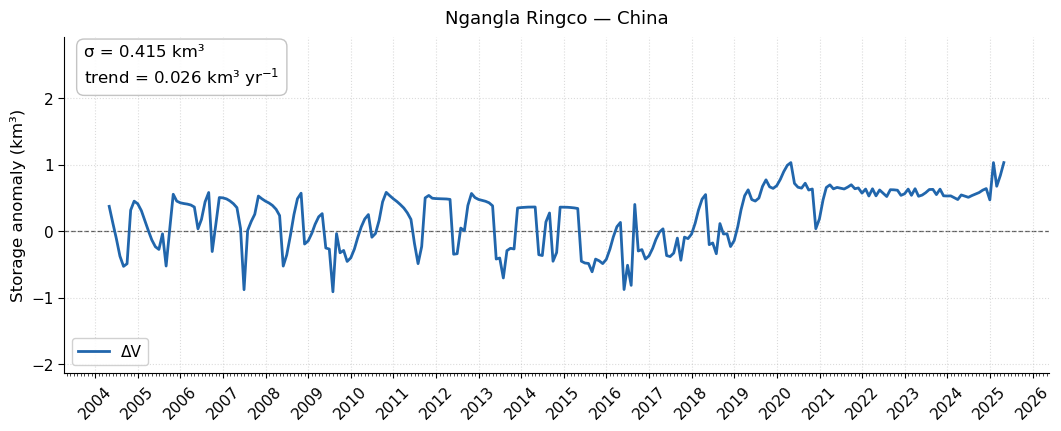

[1431]

In [45]:
from sws_analysis_utils import plot_example_lake_volumes
plot_example_lake_volumes(ranked_catalog, 
                            volume_series, 
                            n_lakes=1, 
                            )

### GRACE pixel assignment (`GRACE_WINDOW_DEG`)

Each lake centroid is mapped to the **nearest GRACE grid cell centre** (haversine). Lake ΔV is spread over that pixel's footprint for cm comparison. GRACE TWSA is used **as-is** (solution anomalies; no extra 2004–2009 baseline removal).

| `GRACE_WINDOW_DEG` | GRACE / precip extraction | Lake ΔV footprint |
|--------------------|---------------------------|-------------------|
| **1** | Single assigned 1° cell | 1°×1° at assigned centre |
| **3** | Mean of 3×3 cells around assigned centre | 3°×3° at assigned centre |

**`aggregate_by_grace_pixel=True`:** lakes with the same `(grace_lat, grace_lon)` have their **ΔV (km³) summed first**, then converted once to cm and compared to one GRACE series. Variances are computed on that combined cm series (not by summing per-lake variances).

In [62]:
GRACE_WINDOW_DEG = 1  # use 3.0 to compare wider GRACE/precip windows
lake_percent_thrshold = 20

In [71]:
from sws_analysis_utils import analyze_lake_grace_comparisons

AGGREGATE_BY_GRACE_PIXEL = True
SAVE_FIGURES = False  # True → saves to cfg.figures_dir with progress bar (no inline display)
CALCULATE_RESIDUAL = True
lake_summary, saved_plots = analyze_lake_grace_comparisons(
    ranked_catalog,
    volume_series,
    grace_mean,
    precip_gridded,
    cfg=cfg,
    window_deg=GRACE_WINDOW_DEG,
    aggregate_by_grace_pixel=AGGREGATE_BY_GRACE_PIXEL, #sum the volume of all lakes within one grace pixel
    save_figures=SAVE_FIGURES,
    calculate_residual=CALCULATE_RESIDUAL,
    parallel=True,
)


  GRACE pixel summaries (678 pixels, 1416 lakes)...


  GRACE pixels:   0%|          | 0/678 [00:00<?, ?pixel/s]

INFO: GRACE pixel summary (678 pixels, 1416 lakes grouped) → /mnt/d/grace_ds/data/SWS/processed/grace_pixel_summary_win1.csv


### Lake σ vs GRACE σ — maps & distribution

Per-lake stats (polygons + centroids). If `lake_summary` is pixel-aggregated, per-lake rows are recomputed automatically for these plots.

In [72]:
lake_summary

,grace_lat,grace_lon,n_lakes,lake_ids,lake_names,country,area_km2,completeness_pct,window_deg,grace_window_area_km2,lake_std_cm,grace_std_cm,lake_std_pct_of_grace,lake_std_cm_residual,grace_std_cm_residual,lake_std_pct_of_grace_residual,lake_trend_cm_yr,grace_trend_cm_yr,n_overlap_months
0,-49.5,-71.5,1,123672,No Name,Argentina,5.40,50.78,1,8048.05,0.05,30.12,0.164994,0.02,5.31,0.44,-0.01,-5.59,190
1,-49.5,-69.5,1,123614,No Name,Argentina,4.56,34.88,1,8048.05,0.18,14.92,1.174949,0.13,3.37,3.83,-0.02,-2.31,152
2,-48.5,-71.5,1,123548,No Name,Argentina,5.25,44.19,1,8211.28,0.06,28.91,0.196382,0.04,4.96,0.89,-0.01,-6.07,181
3,-48.5,-68.5,1,123532,No Name,Argentina,3.74,14.73,1,8211.28,0.07,8.00,0.915077,0.06,2.74,2.06,0.03,-1.32,43
4,-48.5,-67.5,1,123555,No Name,Argentina,2.49,31.01,1,8211.28,NaN,NaN,NaN,NaN,NaN,NaN,-0.00,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673,50.5,61.5,3,"166651,166754,166636",No Name; No Name; No Name,Kazakhstan,7.35,39.02,1,7882.37,NaN,NaN,NaN,NaN,NaN,NaN,-0.01,NaN,0
674,50.5,64.5,10,"1216,13766,166969,166822,166613,166040,166617,...",No Name; No Name; No Name; No Name; No Name; N...,Kazakhstan,200.19,35.78,1,7882.37,0.91,5.09,17.798598,0.84,3.01,27.78,0.02,0.33,223
675,50.5,65.5,4,"166785,166813,166854,166824",No Name; No Name; No Name; No Name,Kazakhstan,6.36,39.44,1,7882.37,0.03,5.37,0.615894,0.03,3.15,0.81,0.00,0.40,217
676,50.5,68.5,2,"13776,166941",No Name; No Name,Kazakhstan,66.92,40.50,1,7882.37,NaN,NaN,NaN,NaN,NaN,NaN,0.16,NaN,0


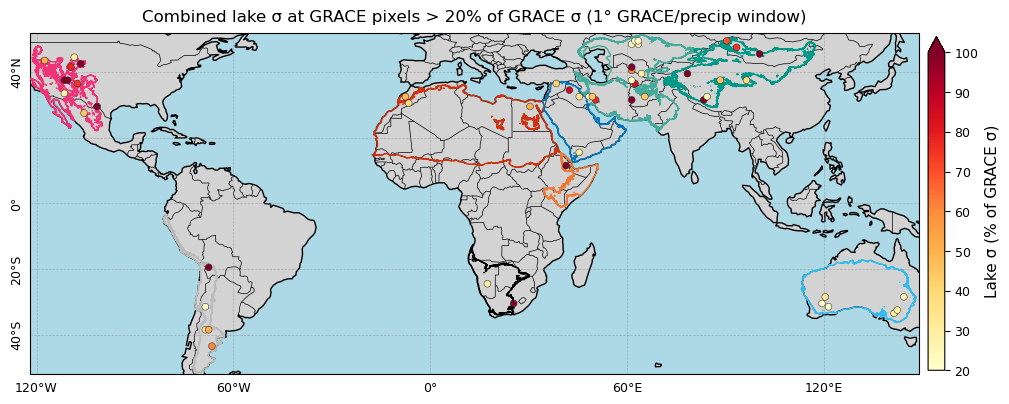

53 GRACE pixels with lake_std_pct_of_grace > 20% of GRACE σ (sorted highest to lowest)


In [74]:
from sws_analysis_utils import  load_arid_domains,plot_lake_std_ratio_map

SUMMARY_MODE = "grace_pixel" if AGGREGATE_BY_GRACE_PIXEL else "per_lake"
domains_gdf = load_arid_domains(cfg=cfg)
filtered_lake_std  = plot_lake_std_ratio_map(
    lake_summary,
    ranked_catalog,
    volume_series=volume_series,
    grace_da=grace_mean,
    cfg=cfg,
    summary_mode=SUMMARY_MODE,
    window_deg=GRACE_WINDOW_DEG,
    domains_gdf=domains_gdf,
    draw_domain_boundaries=True,
    #save_path=cfg.figures_dir / f"lake_std_ratio_global_win{GRACE_WINDOW_DEG}.jpeg",
    figsize=(10, 4),
    vmax=100,
    point_size=24,
    min_pct= lake_percent_thrshold,      # default; use None or 0 for all lakes
    return_table=True,
    filter_mode = "anomaly",   # "anomaly" or "residual"
    show=True,
)


In [ ]:
from sws_analysis_utils import export_lake_std_ratio_shapefile

shp_path = cfg.shapefiles_dir / f"lake_std_ratio_{SUMMARY_MODE}_win{GRACE_WINDOW_DEG}_thr{lake_percent_thrshold}.shp"
filtered_lake_std_gdf = export_lake_std_ratio_shapefile(
    filtered_lake_std,
    summary_mode=SUMMARY_MODE,
    #save_path=shp_path,
)

/mnt/d/codes/python/grace_ds/GRACE_ds_subbasin_Analysis/Cursor/SWS/sws_analysis_utils.py:4297: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(save_path)
/home/hcg0037/anaconda3/envs/rapids/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lake_std_cm' to 'lake_std_c'
  ogr_write(
/home/hcg0037/anaconda3/envs/rapids/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'grace_std_cm' to 'grace_std_'
  ogr_write(
/home/hcg0037/anaconda3/envs/rapids/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lake_var_cm2' to 'lake_var_c'
  ogr_write(
/home/hcg0037/anaconda3/envs/rapids/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'grace_var_cm2' to 'grace_var_'
  ogr_write(
INFO: Created 3 records


Exported 3 GRACE pixel(s) to /mnt/d/grace_ds/data/SWS/shapefiles/lake_std_ratio_grace_pixel_win3_thr20.shp


In [ ]:
from sws_analysis_utils import plot_lake_std_ratio_maps_by_domain
domain_figs = plot_lake_std_ratio_maps_by_domain(
    lake_summary,
    ranked_catalog,
    volume_series,
    grace_mean,
    cfg=cfg,
    window_deg=GRACE_WINDOW_DEG,
    #save_dir=cfg.figures_dir / f"lake_std_ratio_domains_win{GRACE_WINDOW_DEG}",
    show=True,
    print_lake_names=True,
    summary_mode=SUMMARY_MODE,
    include_global=False,   # domain maps only
    adaptive_figsize=True,
    vmax=100,
    point_size=24,
    min_pct=lake_percent_thrshold,      # default; use None or 0 for all lakes
)


In [66]:
from sws_analysis_utils import plot_filtered_lake_std_comparisons

SAVE_FILTERED_FIGURES = True  # True -> saves each filtered lake/pixel comparison figure to cfg.figures_dir

saved_filtered_plots = plot_filtered_lake_std_comparisons(
    filtered_lake_std,
    ranked_catalog,
    volume_series,
    grace_mean,
    precip_da=precip_gridded,
    cfg=cfg,
    window_deg=GRACE_WINDOW_DEG,
    summary_mode=SUMMARY_MODE,
    save_figures=SAVE_FILTERED_FIGURES,
    show=not SAVE_FILTERED_FIGURES,
)

  Saving filtered figures:   0%|          | 0/53 [00:00<?, ?fig/s]

INFO: Saved 53 filtered lake/GRACE/precip plots to /mnt/d/grace_ds/data/SWS/figures
